# Derivación de Backpropagation

Sea una capa de una red neuronal definida por

$$
z = aW + b
$$

donde:

- $a$ son las activaciones de la capa anterior,
- $W$ es la matriz de pesos,
- $b$ es el vector de sesgos (biases).

La salida de la capa se obtiene aplicando una función de activación

$$
a = f(z).
$$

Sea además una función de costo

$$
J(a,y),
$$

donde $y$ corresponde a la salida esperada.

Nuestro objetivo es calcular cómo cambia el costo cuando modificamos los pesos y los sesgos de la red.

---

# Derivada respecto a un peso

Consideremos un único peso $w_{ij}$.

El costo depende de este peso únicamente a través de la siguiente cadena de dependencias:

$$
w_{ij}
\rightarrow
z_j
\rightarrow
a_j
\rightarrow
J.
$$

Aplicando la regla de la cadena,

$$
\frac{\partial J}{\partial w_{ij}}
=
\frac{\partial J}{\partial a_j}
\frac{\partial a_j}{\partial z_j}
\frac{\partial z_j}{\partial w_{ij}}.
$$

Como

$$
a_j=f(z_j),
$$

se tiene

$$
\frac{\partial a_j}{\partial z_j}
=
f'(z_j).
$$

Además,

$$
z_j
=
\sum_i a_iw_{ij}+b_j,
$$

por lo que

$$
\frac{\partial z_j}{\partial w_{ij}}
=
a_i.
$$

Sustituyendo estas expresiones en la ecuación anterior,

$$
\frac{\partial J}{\partial w_{ij}}
=
\frac{\partial J}{\partial a_j}
f'(z_j)
a_i.
$$

Observemos ahora que el término

$$
\frac{\partial J}{\partial a_j}
f'(z_j)
$$

aparece constantemente durante la derivación. Por esta razón se define

$$
\delta_j
=
\frac{\partial J}{\partial z_j}
=
\frac{\partial J}{\partial a_j}
f'(z_j).
$$

Finalmente,

$$
\frac{\partial J}{\partial w_{ij}}
=
a_i\delta_j.
$$

En consecuencia, el gradiente de un peso es el producto entre la activación de la neurona de entrada y el error asociado a la neurona de salida.

Si se consideran simultáneamente todos los pesos de la capa, la expresión anterior puede escribirse en forma matricial como

$$
\frac{\partial J}{\partial W}
=
a^T\delta.
$$

Esta es precisamente la operación implementada en código mediante

```python
dW = A.T @ delta
```

---

# Derivada respecto al bias

Procedemos de la misma manera.

Aplicando nuevamente la regla de la cadena,

$$
\frac{\partial J}{\partial b_j}
=
\frac{\partial J}{\partial a_j}
\frac{\partial a_j}{\partial z_j}
\frac{\partial z_j}{\partial b_j}.
$$

Ya conocemos los dos primeros factores.

Solo falta calcular

$$
\frac{\partial z_j}{\partial b_j}.
$$

Como

$$
z_j
=
\sum_i a_iw_{ij}+b_j,
$$

se obtiene

$$
\frac{\partial z_j}{\partial b_j}
=
1.
$$

Por tanto,

$$
\frac{\partial J}{\partial b_j}
=
\frac{\partial J}{\partial a_j}
f'(z_j).
$$

Utilizando la definición de $\delta_j$,

$$
\frac{\partial J}{\partial b_j}
=
\delta_j.
$$

Cuando el entrenamiento se realiza utilizando un batch de tamaño $m$, cada ejemplo produce un valor distinto de $\delta$.

Como el bias es compartido por todos los ejemplos del batch, su gradiente corresponde al promedio de todas esas contribuciones,

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{k=1}^{m}
\delta_k.
$$

En NumPy,

```python
db = np.mean(delta, axis=0)
```

---

# Cálculo del término $\delta$

Hasta este punto únicamente se ha definido

$$
\delta
=
\frac{\partial J}{\partial z}.
$$

Ahora se obtendrá una expresión para calcularlo.

Como

$$
a=f(z),
$$

aplicando nuevamente la regla de la cadena,

$$
\frac{\partial J}{\partial z}
=
\frac{\partial J}{\partial a}
\frac{\partial a}{\partial z}.
$$

Pero

$$
\frac{\partial a}{\partial z}
=
f'(z),
$$

por lo que

$$
\delta
=
\frac{\partial J}{\partial a}
\odot
f'(z),
$$

donde $\odot$ representa el producto elemento a elemento.

---

# Delta en la capa de salida

Supóngase que la función de costo es el error cuadrático

$$
J
=
\frac12(a-y)^2.
$$

Derivando respecto a la salida de la red,

$$
\frac{\partial J}{\partial a}
=
a-y.
$$

Sustituyendo en la definición anterior,

$$
\delta^L
=
(a-y)
\odot
f'(z^L).
$$

Esta expresión permite calcular directamente el delta de la última capa.

---

# Delta en una capa oculta

Considérese ahora una capa oculta $l$.

En este caso el costo ya no depende directamente de $a^l$, sino a través de la siguiente capa.

La cadena de dependencias es

$$
z^l
\rightarrow
a^l
\rightarrow
z^{l+1}
\rightarrow
a^{l+1}
\rightarrow
J.
$$

Aplicando nuevamente la regla de la cadena,

$$
\frac{\partial J}{\partial z^l}
=
\frac{\partial J}{\partial z^{l+1}}
\frac{\partial z^{l+1}}{\partial a^l}
\frac{\partial a^l}{\partial z^l}.
$$

Por definición,

$$
\frac{\partial J}{\partial z^{l+1}}
=
\delta^{l+1}.
$$

Además,

$$
z^{l+1}
=
a^lW^{l+1}+b^{l+1},
$$

por lo que

$$
\frac{\partial z^{l+1}}{\partial a^l}
=
(W^{l+1})^T.
$$

Finalmente,

$$
\frac{\partial a^l}{\partial z^l}
=
f'(z^l).
$$

Sustituyendo todas estas expresiones,

$$
\delta^l
=
(W^{l+1})^T
\delta^{l+1}
\odot
f'(z^l).
$$

Esta ecuación permite calcular el error de una capa a partir del error de la siguiente. Comenzando por la capa de salida y repitiendo este procedimiento hasta la primera capa, es posible obtener los gradientes de todos los pesos y biases de la red. Este procedimiento constituye el algoritmo de **Backpropagation**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

n = 500
p = 2

X, y = make_circles(n_samples=n, shuffle=True, noise=0.05, random_state=0, factor=0.5)
y = y[:, np.newaxis]

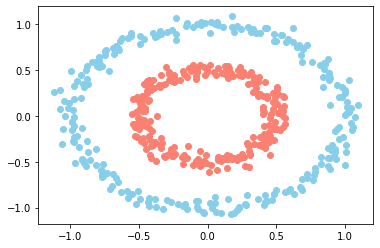

In [ ]:
plt.scatter(X[y[:, 0] == 0,0], X[y[:, 0] == 0,1], c='skyblue')
plt.scatter(X[y[:, 0] == 1,0], X[y[:, 0] == 1,1], c='salmon')
plt.show()

In [ ]:
class capa_neuronal:

  def __init__(self, n_conexiones, n_neuronas, fun_act):
    self.n_conexiones = n_conexiones
    self.n_neuronas = n_neuronas
    self.fun_act = fun_act

    self.b = np.random.rand(1, n_neuronas)*2 - 1
    self.w = np.random.rand(n_conexiones, n_neuronas)*2 - 1

class red_neuronal:

  def __init__(self, topologia, fun_act):
    self.topologia = topologia
    self.fun_act = fun_act
    self.nn = []

  def crear_red(self):
    for i, capa in enumerate(topologia[:-1]):
      self.nn.append(capa_neuronal(self.topologia[i], self.topologia[i+1], self.fun_act))
    return self

  def fit(self, X, y, lr=0.05, train=True):
    fun_cost = (lambda Yp, Yr: np.mean((Yp - Yr)**2),
                lambda Yp, Yr: (Yp - Yr))

    #forward pass
    out = [(None, X)]
    for i, capa in enumerate(self.nn):
      z = out[-1][1] @ self.nn[i].w + self.nn[i].b
      a = self.nn[i].fun_act[0](z)
      out.append((z, a))

    #backpropagation
    if train:
      deltas = []
      for i in reversed(range(0, len(self.nn))):

        z = out[i+1][0]
        a = out[i+1][1]

        if i == len(self.nn) - 1:
          deltas.insert(0, fun_cost[1](a, y) * self.nn[i].fun_act[1](a))
        else:
          deltas.insert(0, deltas[0] @ _w.T * self.nn[i].fun_act[1](a))

        _w = self.nn[i].w

        self.nn[i].b = self.nn[i].b - np.mean(deltas[0], axis=0, keepdims=True) * lr
        self.nn[i].w = self.nn[i].w - out[i][1].T @ deltas[0] * lr

    return out[-1][1]

In [ ]:
#Funciones de activación
sigm = (lambda x: 1/(1 + np.e ** (-x)),
        lambda x: x * (1 - x))

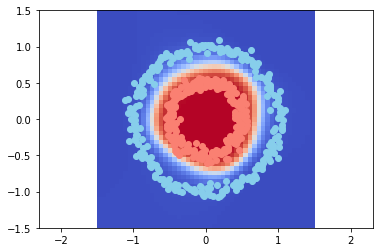

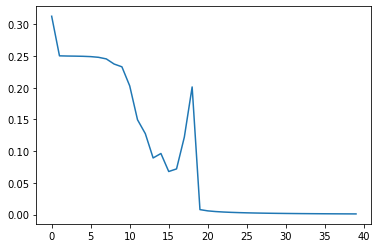

In [ ]:
import time
from IPython.display import clear_output

topologia = [p, 4, 8, 1]
red = red_neuronal(topologia, sigm).crear_red()

loss = []

for i in range(1000):

  Yr = red.fit(X, y)

  if i % 25 == 0:
    loss.append(np.mean((y - Yr)**2))

    res = 50

    _x0 = np.linspace(-1.5, 1.5, res)
    _x1 = np.linspace(-1.5, 1.5, res)

    _y = np.zeros((res, res))

    for _i0, x0 in enumerate(_x0):
      for _j0, x1 in enumerate(_x1):
        _y[_i0, _j0] = red.fit(np.array([[x0, x1]]), y, train=False)

    plt.pcolormesh(_x0, _x1, _y, cmap="coolwarm")
    plt.axis("equal")

    plt.scatter(X[y[:, 0] == 0,0], X[y[:, 0] == 0,1], c='skyblue')
    plt.scatter(X[y[:, 0] == 1,0], X[y[:, 0] == 1,1], c='salmon')

    clear_output(wait=True)
    plt.show()
    plt.plot(range(len(loss)), loss)
    plt.show()
    time.sleep(0.5)